In [13]:
### This noteboook is used for dealing with problem in ContiguousSNP
import sys
import os
import zipfile
from scipy import stats
from scipy.optimize import minimize

## import function from python_scripts
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
from python_scripts.gene_level_MoM import * 
from python_scripts.pairwise_product_var_calculation import * 
from python_scripts.visualization import * 
from python_scripts.weight_function import * 
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.linalg import cholesky
import time

def read_MoM_results_add(individual_sizes, path, file_name, num_snp):
    """
    read_MoM_results from cluster output files with three columns (a, gxg, e).
    parameters:
    individual_sizes: list of individual sizes (e.g., [1000, 2000, 4000])
    path: directory path where the result files are stored
    num_snp: number of SNPs used in the analysis
    file_name: base name of the result files (e.g., "MoM_results")
    returns:
    A dictionary with individual sizes as keys and corresponding DataFrames as values.
    Each DataFrame has three columns: [0]=a (additive), [1]=gxg (epistatic), [2]=e (error).
    """
    data_dict = {}
    for n in individual_sizes:
        full_file_name = f"{file_name}_n{n}m{num_snp}.txt"
        file_path = os.path.join(path, full_file_name)

        df = pd.read_csv(file_path, header=None)
        df[0] = df[0].astype(str).str.replace('(', '', regex=False).astype(float)
        df[1] = df[1].astype(str).astype(float)
        df[2] = df[2].astype(str).str.replace(')', '', regex=False).astype(float)

        data_dict[n] = df

    return data_dict

def plot_relative_error_across_groups_combined(*data_dicts, x_labels, individual_sizes, col_num, real_value, ymin, ymax, x_axis_name="Group", title=None, save_name=None):
    """
    Plot relative errors with box plots in journal style.
    
    Parameters:
    -----------
    col_num : int
        Column index to plot. 
        0 = additive (a), 1 = epistatic (gxg), 2 = error (e)
        For two-column data: 0 = gxg, 1 = e
    save_name : str
        Filename without extension (e.g., 'my_plot'). 
        PDF will be saved to the same directory as the script.
        If None, plot is only displayed.
    """
    
    # Set high-quality rendering
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 10,
        'axes.linewidth': 1,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.width': 1,
        'ytick.major.width': 1,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'figure.dpi': 150,
        'savefig.dpi': 600,
    })
    
    # Gather data for all combinations
    data_list = []
    combined_labels = []
    bottom_labels = []
    
    for label, data_dict in zip(x_labels, data_dicts):
        for n in individual_sizes:
            df = data_dict[n]
            col_values = df.iloc[:, col_num].values - real_value
            combined_labels.append(f"{label}\nn={n:,}")
            bottom_labels.append(f"n = {n:,}")
            data_list.append(pd.DataFrame({"value": col_values, "group": combined_labels[-1]}))
    
    data = pd.concat(data_list, ignore_index=True)
    data["group"] = pd.Categorical(data["group"], categories=combined_labels, ordered=True)
    
    # Compute summary statistics
    summary = (
        data.groupby("group", observed=True)["value"]
        .agg(["mean", "std", "count"])
        .loc[combined_labels]
    )
    
    # Perform one-sample t-test for each group (mean != 0)
    p_values = {}
    for combined_label in combined_labels:
        group_data = data[data["group"] == combined_label]["value"].values
        t_stat, p_val = stats.ttest_1samp(group_data, 0)
        p_values[combined_label] = p_val
    
    summary["p_value"] = summary.index.map(p_values)
    
    # x-axis positions
    x_positions = np.arange(len(summary))
    
    # Create figure
    fig, ax = plt.subplots(figsize=(3 + len(combined_labels) * 0.8, 5))
    
    # Extend y-axis for labels above plot
    ymax_extended = ymax + 0.25 * (ymax - ymin)
    ax.set_ylim(ymin, ymax_extended)
    ax.set_xlim(-0.6, len(combined_labels) - 0.4)
    
    # Add alternating white/gray background for EACH BOX
    for i in range(len(combined_labels)):
        x_start = i - 0.5
        x_end = i + 0.5
        if i % 2 == 0:
            ax.axvspan(x_start, x_end, facecolor='white', alpha=1.0, zorder=0)
        else:
            ax.axvspan(x_start, x_end, facecolor='#E8E8E8', alpha=0.8, zorder=0)
    
    # Prepare data for box plots
    box_data = [data[data["group"] == label]["value"].values for label in combined_labels]
    
    # Define colors
    box_color = '#3274A1'
    median_color = '#CC0000'
    label_color = '#000000'
    
    # Create box plots - NO OUTLIERS
    bp = ax.boxplot(
        box_data,
        positions=x_positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(linewidth=1.5, edgecolor=box_color, facecolor='white'),
        whiskerprops=dict(linewidth=1.2, color=box_color),
        capprops=dict(linewidth=1.2, color=box_color),
        medianprops=dict(linewidth=2, color=median_color)
    )
    
    # Add m = label at top
    for i, label in enumerate(x_labels):
        group_center = (i + 0.5) * len(individual_sizes) - 0.5
        ax.text(
            group_center, ymax_extended - 0.01 * (ymax_extended - ymin),
            label,
            ha='center', va='top', fontsize=11, fontweight='bold', color=label_color
        )
    
    # Significance stars, Mean, and SD labels
    for i, (combined_label, row) in enumerate(summary.iterrows()):
        p_val = row['p_value']
        if p_val < 0.001:
            sig_stars = '***'
        elif p_val < 0.01:
            sig_stars = '**'
        elif p_val < 0.05:
            sig_stars = '*'
        else:
            sig_stars = 'ns'
        
        ax.text(
            i, ymax_extended - 0.08 * (ymax_extended - ymin),
            sig_stars,
            ha='center', va='top', fontsize=11, fontweight='bold',
            color=label_color
        )
        
        ax.text(
            i, ymax_extended - 0.15 * (ymax_extended - ymin),
            f"Mean={row['mean']:.3f}",
            ha='center', va='top', fontsize=9, fontweight='bold',
            color=label_color
        )
        
        ax.text(
            i, ymax_extended - 0.22 * (ymax_extended - ymin),
            f"SD={row['std']:.3f}",
            ha='center', va='top', fontsize=9, fontweight='bold',
            color=label_color
        )
    
    # Determine y-axis label based on col_num
    # Auto-detect based on number of columns in the first DataFrame
    first_df = list(data_dicts[0].values())[0]
    num_cols = first_df.shape[1]
    
    if num_cols == 3:
        # Three-column case: [a, gxg, e]
        if col_num == 0:
            theta_simple = r"$\sigma^2_{a}$"
        elif col_num == 1:
            theta_simple = r"$\sigma^2_{g \times g}$"
        elif col_num == 2:
            theta_simple = r"$\sigma^2_{e}$"
        else:
            theta_simple = "Parameter"
    else:
        # Two-column case: [gxg, e]
        if col_num == 0:
            theta_simple = r"$\sigma^2_{g \times g}$"
        elif col_num == 1:
            theta_simple = r"$\sigma^2_{e}$"
        else:
            theta_simple = "Parameter"
    
    # Reference line at zero
    ax.axhline(0, color='#666666', linestyle='--', linewidth=0.8, zorder=1)
    
    # Axis labels
    ax.set_xlabel("Sample size (n)", fontsize=10, labelpad=8)
    ax.set_ylabel(f"Relative error ({theta_simple})", fontsize=10, labelpad=8)
    
    # Y-axis ticks
    yticks = np.arange(np.ceil(ymin * 4) / 4, ymax + 0.01, 0.25)
    yticks = [y for y in yticks if y <= ymax]
    ax.set_yticks(yticks)
    
    # X-tick labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(bottom_labels, fontsize=9)
    
    # Title
    if title:
        ax.set_title(title, fontsize=11, pad=10, fontweight='normal')
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    
    ax.tick_params(axis='both', which='major', labelsize=9, colors='#333333')
    
    plt.tight_layout()
    
    # Save PDF to script directory
    if save_name:
        script_dir = os.getcwd()
        save_path = os.path.join(script_dir, f"{save_name}.pdf")
        
        plt.savefig(
            save_path,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            format='pdf',
            transparent=False,
            pad_inches=0.1
        )
        print(f"PDF saved to: {save_path}")
    
    plt.show()
    
    # Reset rcParams
    plt.rcParams.update(plt.rcParamsDefault)


In [14]:
###unzip file
zip_files = [
    "../test_data/chr1_Contiguous1KSNP.zip",
    "../test_data/chr1_Random1KSNP.zip"
]
for zf in zip_files:
    with zipfile.ZipFile(zf, "r") as z:
        z.extractall("test_data")   
    print(f"Unzipped: {zf}")
##read data  
##Random snp
RandomSNP = pd.read_csv("test_data/chr1_Random1KSNP.raw", sep=r'\s+')
RandomSNP = RandomSNP.iloc[:, 6:].to_numpy()
##Contiguous snp
ContiguousSNP = pd.read_csv("test_data/chr1_Contiguous1KSNP.raw", sep=r'\s+')
ContiguousSNP = ContiguousSNP.iloc[:, 6:].to_numpy()

Unzipped: ../test_data/chr1_Contiguous1KSNP.zip
Unzipped: ../test_data/chr1_Random1KSNP.zip


In [2]:
###approximate mom
def simulate_Cholesky_from_std_additive(real_data, s2a=0.9, s2e=0.1, stability=1e-10):

    Z = (real_data - real_data.mean(axis=0)) / real_data.std(axis=0)
    n, m = Z.shape

    K = (Z @ Z.T) / m
    Sigma_a = s2a * K + stability * np.eye(n)
    La = cholesky(Sigma_a, lower=True) 
    return La


def simulate_from_raw_additive_remove_sampling_err(real_data, La, s2a=0.9, s2e=0.1):

    Z = (real_data - real_data.mean(axis=0)) / real_data.std(axis=0)
    n, m = Z.shape

    u1 = np.random.randn(n)
    u2 = np.random.randn(n)

    a = La @ u1
    Le = np.sqrt(s2e) * np.eye(n)
    e = Le @ u2

    cur_var_a = np.var(a, ddof=0)
    scale_a = np.sqrt(s2a / cur_var_a)
    a = a * scale_a
    
    cur_var_e = np.var(e, ddof=0)
    scale_e = np.sqrt(s2e / cur_var_e)
    e = e * scale_e
    
    y = a + e
    y -= y.mean()

    return Z, y


def MoM_additive(Z, y, nmc=100):

    n = Z.shape[0]
    m = Z.shape[1]
    u = np.random.choice([-1, 1], size=(n, nmc))

    Ku = (Z @ (Z.T @ u)) / m
    # tr(K)
    trK_app = np.mean(np.sum(u * Ku, axis=0))

    # tr(K^2)
    trK2_app = np.mean(np.sum(Ku * Ku, axis=0))

    # quadratic forms
    Zty = Z.T @ y
    yKy = (Zty @ Zty) / m        # y^T K y = (1/m) ||Z^T y||^2
    yy  = y @ y                  # y^T y

    # MoM linear system: A @ [s2a, s2e].T = b
    A = np.array([[trK2_app, trK_app],
                  [trK_app,  n      ]])
    b = np.array([yKy, yy])

    # Solve A @ [s2a, s2e].T = b
    x = np.linalg.solve(A, b)
    return x[0], x[1], A


def MoM_additive_exact(Z, y):

    n, m = Z.shape

    # tr(K) = (1/m) * sum_j ||Z_j||^2
    # Equals n exactly when Z is column-standardized with ddof=0.
    trK = np.sum(Z * Z) / m

    # tr(K^2) = (1/m^2) * ||Z^T Z||_F^2
    ZtZ = Z.T @ Z
    trK2 = np.sum(ZtZ * ZtZ) / (m * m)

    # y^T K y = (1/m) * ||Z^T y||^2
    Zty = Z.T @ y
    yKy = (Zty @ Zty) / m

    # y^T y
    yy = y @ y

    # MoM 2x2 linear system: A @ [s2a, s2e].T = b
    A = np.array([[trK2, trK],
                  [trK,  n  ]])
    b = np.array([yKy, yy])

    x = np.linalg.solve(A, b)
    return x[0], x[1], A


######### the simulation with gxg
def build_W_batched(Z, pair_batch_size=5000):
    n, m = Z.shape
    p = m * (m - 1) // 2
    
    idx_i, idx_j = np.triu_indices(m, k=1)  # All pairs globally
    
    W = np.zeros((n, n))
    
    for start in range(0, p, pair_batch_size):
        end = min(start + pair_batch_size, p)
        
        # Pairwise products for this batch
        H_batch = Z[:, idx_i[start:end]] * Z[:, idx_j[start:end]]
        
        # Standardize
        mu = H_batch.mean(axis=0)
        sig = H_batch.std(axis=0, ddof=0)
        mask = sig > 1e-10
        H_batch[:, mask] = (H_batch[:, mask] - mu[mask]) / sig[mask]
        H_batch[:, ~mask] = 0.0
        
        W += H_batch @ H_batch.T
    
    W /= p
    return W

def simulate_Cholesky_from_std(real_data, s2gxg=0.9, s2e=0.1, stability=1e-10):
    Z = (real_data - real_data.mean(axis=0)) / real_data.std(axis=0)
    n, m = Z.shape
    W = build_W_batched(Z)
    Lgxg = cholesky(s2gxg * W + stability * np.eye(n), lower=True)
    
    return Lgxg 

def simulate_from_raw_only_W_remove_sampling_err(real_data, Lgxg, s2gxg=0.9, s2e=0.1):

    Z = (real_data - real_data.mean(axis=0)) / real_data.std(axis=0)
    n, m = Z.shape

    u1 = np.random.randn(n)
    u2 = np.random.randn(n)

    gxg = Lgxg @ u1

    Le = np.sqrt(s2e) * np.eye(n)
    e = Le @ u2 

    # eliminate the sampling variances
    cur_var_gxg = np.var(gxg, ddof=0)                 
    scale_g   = np.sqrt(s2gxg / cur_var_gxg)           
    gxg     = gxg * scale_g

    cur_var_e = np.var(e, ddof=0)                 
    scale_e   = np.sqrt(s2e / cur_var_e)           
    e     = e * scale_e
   
    y = gxg + e
    y -= y.mean()

    return  Z, y


def compute_weight_matrices(Z):
    n, m = Z.shape
    
    ZTZ = Z.T @ Z
    E_ZaZb = ZTZ / n
    
    D = Z * Z
    DTD = D.T @ D
    term1 = DTD / n

    term2 = E_ZaZb * E_ZaZb
    
    V = term1 - term2
    
    S = 1.0 / V
    R = E_ZaZb / V
    T = term2 / V
    
    np.fill_diagonal(S, 0)
    np.fill_diagonal(R, 0)
    np.fill_diagonal(T, 0)
    
    return S, R, T


def compute_WU(Z, U, S, R, T):

    n, m = Z.shape
    nmc = U.shape[1]
    p = m * (m - 1) // 2
    
    ZR = Z @ R
    term2_base = 0.5 * np.sum(Z * ZR, axis=1, keepdims=True)
    sum_T = 0.5 * np.sum(T)
    sum_U = np.sum(U, axis=0, keepdims=True)
    
    term2 = term2_base @ sum_U
    term4 = sum_T * np.ones((n, 1)) @ sum_U
    
    term1 = np.zeros((n, nmc))
    term3 = np.zeros((n, nmc))
    
    for k in range(nmc):
        u = U[:, k]
        M = Z.T @ (u[:, np.newaxis] * Z)
        SM = S * M
        term1[:, k] = 0.5 * np.sum(Z * (Z @ SM), axis=1)
        term3[:, k] = 0.5 * np.sum(R * M)
    
    return (term1 - term2 - term3 + term4) / p


def MoM_only_M_std(Z, y, nmc=100):
    
    n = Z.shape[0]
    m = Z.shape[1]
    p = m * (m - 1) / 2 

    S, R, T = compute_weight_matrices(Z)
    
    # Random vectors for stochastic trace estimation
    u = np.random.choice([-1, 1], size=(n, nmc))
    
    # Compute Wu using standardized W
    Wu = compute_WU(Z, u, S, R, T)  # This should return W @ u
    
    # tr(W) estimation: tr(W) = mean(u.T @ W @ u)
    trW_app = np.mean(np.sum(u * Wu, axis=0))
    
    # tr(W^2) estimation: tr(W^2) = mean(||W @ u||^2)
    trW2_app = np.mean(np.sum(Wu * Wu, axis=0))
    
    # Quadratic forms
    yTy = y @ y
    
    # y.T @ W @ y - need to compute W @ y first
    y_col = y.reshape(-1, 1)
    Wy = compute_WU(Z, y_col, S, R, T).flatten()  # W @ y
    yTWy = y @ Wy
    
    # Solve moment equations
    # E[y.T @ W @ y] = s2gxg * tr(W^2) + s2e * tr(W)
    # E[y.T @ y] = s2gxg * tr(W) + s2e * n
    A = np.array([
        [trW2_app, trW_app],
        [trW_app, n]
    ])
    
    b = np.array([yTWy, yTy])
    
    # Solve A @ [s2gxg, s2e].T = b
    x = np.linalg.solve(A, b)

    return x[0], x[1], A
    
def compute_effective_M(X):
   
    n, m = X.shape
    
    # Standardize genotypes (column-wise)
    Z = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
    
    # Compute GRM: K = Z Z^T / m
    K = Z @ Z.T / m
    
    # Variance of off-diagonal elements
    mask = ~np.eye(n, dtype=bool)
    var_off_diag = np.var(K[mask], ddof=1)
    
    # Effective number of markers
    M_e = 1 / var_off_diag
    
    return M_e, n, m

**Use hapgene2 data**

**1. additive show the same property**

In [199]:
X = ContiguousSNP[:2000, ]
La = simulate_Cholesky_from_std_additive(X, s2a=0.9, s2e=0.1, stability=1e-10)

n_rep = 300
results_a = np.zeros(n_rep)
results_e = np.zeros(n_rep)

for rep in range(n_rep):
    Z, y = simulate_from_raw_additive_remove_sampling_err(X, La, s2a=0.9, s2e=0.1)
    s2a_hat, s2e_hat, _ = MoM_additive(Z, y)
    results_a[rep] = s2a_hat
    results_e[rep] = s2e_hat

print(f"s2a: Mean = {results_a.mean():.4f}, SD = {results_a.std(ddof=1):.4f}")
print(f"s2e: Mean = {results_e.mean():.4f}, SD = {results_e.std(ddof=1):.4f}")

s2a: Mean = 0.8076, SD = 0.3531
s2e: Mean = 0.1953, SD = 0.3436


**2. Same problem for gxg**

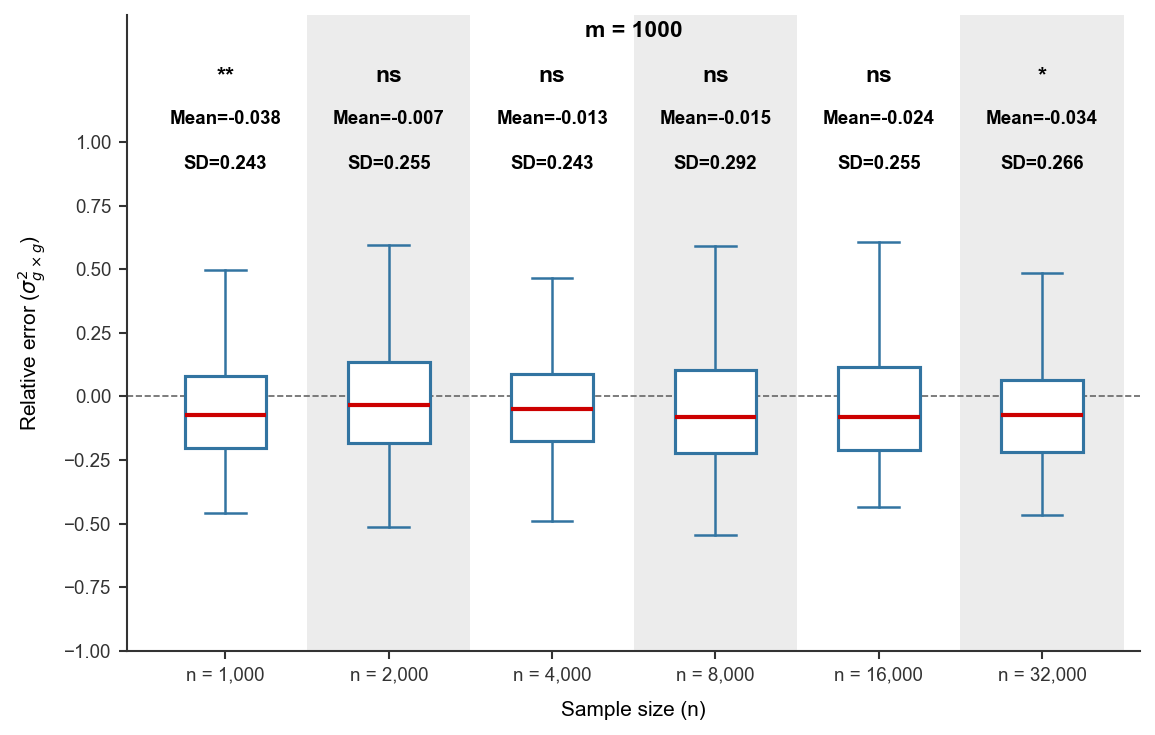

In [9]:
individual_sizes = [1000,2000,4000,8000,16000,32000]
Random1k = read_MoM_results(individual_sizes,"../Thesis/OnlyW_data/","infinitesimal_Contiguous_STD",1000)
plot_relative_error_across_groups_combined(
    Random1k,
    x_labels=["m = 1000"],
    individual_sizes = [1000,2000,4000,8000,16000,32000],
    col_num=0,
    real_value=0.9,
    ymin=-1.0,
    ymax=1.0,
)

**Use Simulation data**

In [10]:
def simulate_genotype(n, m, n_causal, rho=0.9):
    # Causal SNP positions (centers of evenly spaced segments)
    space = m / n_causal
    causal_indices = ((np.arange(n_causal) + 0.5) * space).astype(int)
    causal_set = set(causal_indices.tolist())

    # allele frequencies
    p = np.random.uniform(0.05, 0.95, size=m)
    genotype = np.zeros((n, m), dtype=np.int8)

    # causal SNPs 
    for c in causal_indices:
        genotype[:, c] = np.random.binomial(2, p[c], size=n)

    # tag SNPs 
    for j in range(m):
        if j in causal_set:
            continue

        # nearest causal SNP
        d = np.abs(causal_indices - j)
        c = causal_indices[d.argmin()]

        copy_mask = np.random.random(n) < rho

        # Copied entries
        genotype[copy_mask, j] = genotype[copy_mask, c]

        n_indep = int((~copy_mask).sum())
        if n_indep > 0:
            genotype[~copy_mask, j] = np.random.binomial(2, p[j], size=n_indep)

    return genotype

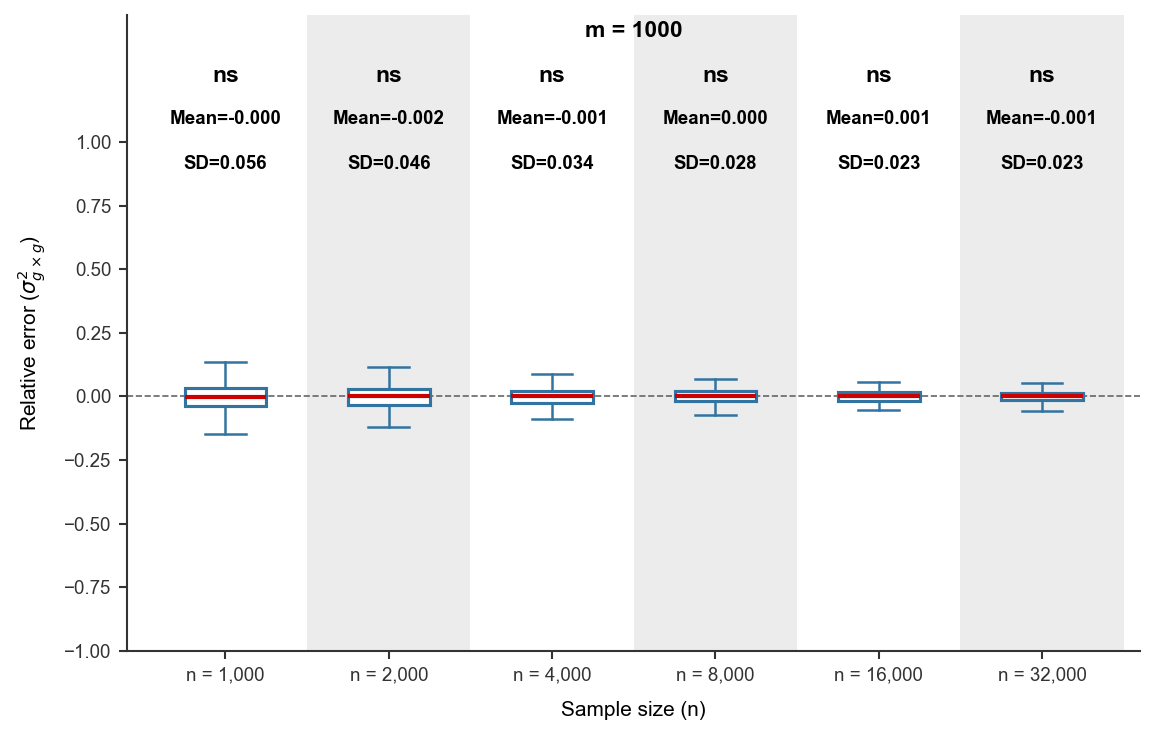

In [11]:
individual_sizes = [1000,2000,4000,8000,16000,32000]
Random1k = read_MoM_results(individual_sizes,"../Thesis/OnlyW_data/","Special_Contiguous_s2gxg0.9_s2e0.1",1000)
plot_relative_error_across_groups_combined(
    Random1k,
    x_labels=["m = 1000"],
    individual_sizes = [1000,2000,4000,8000,16000,32000],
    col_num=0,
    real_value=0.9,
    ymin=-1.0,
    ymax=1.0,
)

**3. check for M**

In [15]:
n = 1000
m = 1000
n_causal = 13 
X = simulate_genotype(n, m, n_causal, rho=1)
print(f"effective number of SNP for simulated genotype {compute_effective_M(X)[0].item():.4f}")

X = ContiguousSNP[:1000, ]
print(f"effective number of SNP for hapgene2 genotype {compute_effective_M(X)[0].item():.4f}")

effective number of SNP for simulated genotype 13.0304
effective number of SNP for hapgene2 genotype 13.0766


**Difference between simulated dataset and Hapgene2 dataset (same M)**

the constent SE may not due to M onlys


In [16]:
def top_k_GRM_eigvals(X, k=13):
    Z = (X - X.mean(axis=0)) / X.std(axis=0)
    K = (Z @ Z.T) / Z.shape[1]
    eigvals = np.linalg.eigvalsh(K)  
    return eigvals[-k:][::-1]

X1 = simulate_genotype(1000, 1000, 13, rho=1)
print("simulation:", top_k_GRM_eigvals(X1))

X2 = ContiguousSNP[:1000, ]
print("HAPGEN2:   ", top_k_GRM_eigvals(X2))

simulation: [90.95704451 87.67595931 85.55832552 84.26936019 81.00289059 78.14887709
 77.50678697 76.16376675 73.34698086 69.49419312 67.64013293 65.37163897
 62.86404319]
HAPGEN2:    [205.0342947  108.70023891  79.07246664  69.03375872  55.55954051
  47.64098084  39.53708738  36.69301591  32.25873445  28.29925744
  26.28243971  21.52425124  18.48791445]


The top eigen value increase with the increase of n

n = 100 labmda1 = 21.87

n = 200 labmda1 = 43.05

n = 1000 labmda1 = 205.0342947